# 📝 Procesamiento y Minería de Textos desde PDF

Este notebook documenta paso a paso el flujo de procesamiento de un archivo PDF para minería de textos, mostrando cada etapa con explicaciones, visualizaciones y mejoras visuales.

## 📦 Importación de librerías
Importamos todas las librerías necesarias para el procesamiento de texto, manejo de PDF, visualización y análisis.

In [2]:
# Importación de librerías necesarias
import os
import re
import unicodedata
import nltk
import chardet
import pdfplumber
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from langdetect import detect
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer

## ⬇️ Descarga de recursos NLTK
Descargamos los recursos esenciales de NLTK para procesamiento de texto en español.

In [3]:
# Descarga de recursos NLTK
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\izurita\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\izurita\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\izurita\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\izurita\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

##  ⚙️ Configuración general
Definimos las rutas de archivos y parámetros generales como el nombre del PDF y el máximo de caracteres a mostrar.

In [4]:
# Configuración general
ARCHIVO_PDF = "F:/Modulo 14 Mineria de Datos/Semana 2/domingo/prueba.pdf"
MAX_CARACTERES = 3000

## 🛠️ Funciones auxiliares
Incluimos funciones reutilizables como `mostrar_titulo` (mejorada con iconos) y `normalizar_texto` para el flujo del procesamiento.

In [5]:
# Funciones auxiliares mejoradas
from IPython.display import display, Markdown

def mostrar_titulo(texto, icono="🔹"):
    display(Markdown(f"\n### {icono} {texto}"))

def normalizar_texto(texto):
    """
    Normalización textual:
    - minúsculas
    - eliminación de acentos
    - espacios redundantes
    """
    texto = texto.lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

# 🏁 Etapa 0 - Preparación de fuentes


## 📄 Verificación de existencia del PDF
Verificamos si el archivo PDF existe y mostramos un mensaje con iconos de advertencia o éxito.

In [6]:
import sys
if not os.path.exists(ARCHIVO_PDF):
    display(Markdown("❌ **No se encontró el archivo:** " + ARCHIVO_PDF))
    sys.exit(1)
else:
    display(Markdown(f"✅ **Archivo encontrado:** `{ARCHIVO_PDF}`"))

✅ **Archivo encontrado:** `F:/Modulo 14 Mineria de Datos/Semana 2/domingo/prueba.pdf`

## 📏 Control de tamaño del archivo
Calculamos y mostramos el tamaño del archivo PDF en MB y bytes, usando iconos para resaltar la información.

In [7]:
tamaño_bytes = os.path.getsize(ARCHIVO_PDF)
tamaño_mb = tamaño_bytes / (1024 * 1024)
display(Markdown(f"📦 **Tamaño del archivo:** `{tamaño_mb:.2f} MB`  \\ 🗂️ **Bytes:** `{tamaño_bytes}`"))

📦 **Tamaño del archivo:** `1.02 MB`  \ 🗂️ **Bytes:** `1068402`

# 📥 Etapa 1 - Adquisición de fuentes

## 📑 Extracción de texto desde PDF
Extraemos el texto de cada página del PDF usando pdfplumber y concatenamos el contenido.

In [8]:
texto_original = ""
with pdfplumber.open(ARCHIVO_PDF) as pdf:
    for pagina in pdf.pages:
        contenido = pagina.extract_text()
        if contenido:
            texto_original += contenido + " "
display(Markdown(f"📝 **Texto extraído de {len(pdf.pages)} páginas.**"))

📝 **Texto extraído de 127 páginas.**

## 🧬 Verificación de codificación
Detectamos la codificación del texto extraído y la mostramos con un icono informativo.

In [9]:
codificacion = chardet.detect(texto_original.encode())["encoding"]
display(Markdown(f"🔤 **Codificación detectada:** `{codificacion}`"))

🔤 **Codificación detectada:** `utf-8`

## 🌐 Detección de idioma
Detectamos el idioma principal del texto usando langdetect y lo mostramos con un icono de bandera.

In [10]:
idioma_detectado = detect(texto_original)
icono_idioma = "🇪🇸" if idioma_detectado == "es" else "🌐"
display(Markdown(f"{icono_idioma} **Idioma detectado:** `{idioma_detectado}`"))

🇪🇸 **Idioma detectado:** `es`

# 🧹 Etapa 2 - Limpieza del texto

## 🧽 Limpieza básica
Eliminamos saltos de línea, caracteres especiales y espacios redundantes del texto.

In [11]:
texto_limpio = re.sub(r"\n", " ", texto_original)
texto_limpio = re.sub(r"[^a-zA-Z0-9áéíóúñüÁÉÍÓÚÑÜ\s]", " ", texto_limpio)
texto_limpio = re.sub(r"\s+", " ", texto_limpio).strip()
display(Markdown("🧽 **Texto limpio (primeros 300 caracteres):**<br>" + texto_limpio[:300] + "…"))

🧽 **Texto limpio (primeros 300 caracteres):**<br>UNIVERSIDAD MAYOR DE SAN ANDRÉS FACULTAD DE DERECHO Y CICENCIAS POLÍTICAS CARRERA DE DERECHO B IBLIOTECA P ROCESO DE DIGITALIZACIÓN Del fondo bibliográfico DE LA BIBLIOTECA DE DERECHO GESTION 2017 Nota importante para el usuario Todo tipo de reproducción del presente documento siempre hacer mención …

## 🚫 Eliminación de ruido
Eliminamos URLs, números y otros elementos no deseados del texto.

In [12]:
texto_limpio = re.sub(r"https?:\/\/\S+", "", texto_limpio)
texto_limpio = re.sub(r"\d+", " ", texto_limpio)
texto_limpio = re.sub(r"\s+", " ", texto_limpio).strip()
display(Markdown("🚫 **Texto sin ruido (primeros 300 caracteres):**<br>" + texto_limpio[:300] + "…"))

🚫 **Texto sin ruido (primeros 300 caracteres):**<br>UNIVERSIDAD MAYOR DE SAN ANDRÉS FACULTAD DE DERECHO Y CICENCIAS POLÍTICAS CARRERA DE DERECHO B IBLIOTECA P ROCESO DE DIGITALIZACIÓN Del fondo bibliográfico DE LA BIBLIOTECA DE DERECHO GESTION Nota importante para el usuario Todo tipo de reproducción del presente documento siempre hacer mención de la…

## 🧾 Normalización
Convertimos el texto a minúsculas, eliminamos acentos y normalizamos espacios.

In [13]:
texto_normalizado = normalizar_texto(texto_limpio)
display(Markdown("🧾 **Texto normalizado (primeros 300 caracteres):**<br>" + texto_normalizado[:300] + "…"))

🧾 **Texto normalizado (primeros 300 caracteres):**<br>universidad mayor de san andres facultad de derecho y cicencias politicas carrera de derecho b iblioteca p roceso de digitalizacion del fondo bibliografico de la biblioteca de derecho gestion nota importante para el usuario todo tipo de reproduccion del presente documento siempre hacer mencion de la…

## ✂️ Tokenización
Tokenizamos el texto en palabras y oraciones usando NLTK, mostrando ejemplos con iconos.

In [14]:
tokens_palabras = word_tokenize(texto_normalizado)
tokens_oraciones = sent_tokenize(texto_normalizado)
display(Markdown(f"✂️ **Cantidad total de tokens:** `{len(tokens_palabras)}`<br>📝 **Primeros 20 tokens:** {tokens_palabras[:20]}"))

✂️ **Cantidad total de tokens:** `26840`<br>📝 **Primeros 20 tokens:** ['universidad', 'mayor', 'de', 'san', 'andres', 'facultad', 'de', 'derecho', 'y', 'cicencias', 'politicas', 'carrera', 'de', 'derecho', 'b', 'iblioteca', 'p', 'roceso', 'de', 'digitalizacion']

## 🛑 Eliminación de stopwords
Eliminamos palabras vacías (stopwords) en español y mostramos la cantidad de tokens resultantes.

In [15]:
stopwords_es = set(stopwords.words("spanish"))
tokens_sin_stopwords = [palabra for palabra in tokens_palabras if palabra not in stopwords_es]
display(Markdown(f"🛑 **Tokens sin stopwords:** `{len(tokens_sin_stopwords)}`<br>🔎 **Primeros 20 tokens limpios:** {tokens_sin_stopwords[:20]}"))

🛑 **Tokens sin stopwords:** `14500`<br>🔎 **Primeros 20 tokens limpios:** ['universidad', 'mayor', 'san', 'andres', 'facultad', 'derecho', 'cicencias', 'politicas', 'carrera', 'derecho', 'b', 'iblioteca', 'p', 'roceso', 'digitalizacion', 'fondo', 'bibliografico', 'biblioteca', 'derecho', 'gestion']

## 📃 Documento final procesado
Unimos los tokens limpios en un solo string para análisis posterior.

In [16]:
documento_final = " ".join(tokens_sin_stopwords)
display(Markdown("📃 **Documento final listo para análisis (primeros 300 caracteres):**<br>" + documento_final[:300] + "…"))

📃 **Documento final listo para análisis (primeros 300 caracteres):**<br>universidad mayor san andres facultad derecho cicencias politicas carrera derecho b iblioteca p roceso digitalizacion fondo bibliografico biblioteca derecho gestion nota importante usuario tipo reproduccion presente documento siempre hacer mencion fuente autor repositorio digital evitar cuestiones l…

# 🧪 Etapa 3 - Preparación para el análisis
Presentamos el inicio de la preparación para análisis y mostramos un título decorativo con iconos.

In [17]:
mostrar_titulo("ETAPA 3 - PREPARACIÓN PARA EL ANÁLISIS", icono="🧪")


### 🧪 ETAPA 3 - PREPARACIÓN PARA EL ANÁLISIS

## 🌱 Stemming
Aplicamos stemming a los tokens y mostramos una tabla comparativa de palabras originales y sus raíces.

In [18]:
stemmer = SnowballStemmer("spanish")
stems = [stemmer.stem(palabra) for palabra in tokens_sin_stopwords]
import pandas as pd
df_stemming = pd.DataFrame({"Palabra": tokens_sin_stopwords[:30], "Stem": stems[:30]})
display(df_stemming.style.set_caption("🌱 Stemming: Palabra original vs raíz"))

,Palabra,Stem
0,universidad,univers
1,mayor,mayor
2,san,san
3,andres,andres
4,facultad,facult
5,derecho,derech
6,cicencias,cicenci
7,politicas,polit
8,carrera,carrer
9,derecho,derech


## 🍃 Lematización
Aplicamos lematización y mostramos una tabla comparativa de palabras originales y sus lemas.

In [19]:
lemmatizer = WordNetLemmatizer()
lemmas = [lemmatizer.lemmatize(palabra) for palabra in tokens_sin_stopwords]
df_lemmatization = pd.DataFrame({"Palabra": tokens_sin_stopwords[:30], "Lema": lemmas[:30]})
display(df_lemmatization.style.set_caption("🍃 Lematización: Palabra original vs lema"))

,Palabra,Lema
0,universidad,universidad
1,mayor,mayor
2,san,san
3,andres,andres
4,facultad,facultad
5,derecho,derecho
6,cicencias,cicencias
7,politicas,politicas
8,carrera,carrera
9,derecho,derecho


## 📊 Matriz DTM
Construimos la matriz Documento-Término (DTM) usando CountVectorizer y la mostramos como DataFrame.

In [20]:
corpus = [documento_final]
vectorizer = CountVectorizer()
dtm = vectorizer.fit_transform(corpus)
vocabulario = vectorizer.get_feature_names_out()
df_dtm = pd.DataFrame(dtm.toarray(), columns=vocabulario)
display(df_dtm.style.set_caption("📊 Matriz Documento-Término (DTM)"))

,aa,abandonar,abandonarme,abarca,abarcando,abel,abierta,abiertos,abogado,abogadoperu,abolicion,abordo,abrieron,abrigo,abril,abrir,abrogarla,absoluta,absoluto,absolutos,abstencion,abstracciones,abuelo,abundantemente,abuso,abusos,aca,acabando,acabar,acabaron,acabo,acarrea,acarreando,acaso,acatan,acatar,acceder,acceso,accion,acciones,acelerado,aceptado,aceptar,acerca,achacachi,acicate,aclarando,acompane,acontecer,acontecian,acontecidos,acontecieron,acontecimiento,acontecimientos,acordado,acordados,acordes,acordo,acostumbrados,actitud,actitudes,activa,actividad,actividades,activo,activos,acto,actor,actores,actos,actual,actualidad,actualizadas,actualmente,actuar,actuare,acuerdo,acuerdos,acumulacion,acumulado,acumulativo,acusado,adecuada,adecuadamente,adecuado,adecuar,adelantadas,adelante,ademas,adenauer,adhesion,adhiere,adicionalmente,adjudicarle,administracion,administrado,administrador,administrativa,administrativas,administrativo,administrativos,adolecera,adopta,adoptada,adoptar,adopto,adquiere,adquiriendo,adquisitivo,adversa,adversas,advertir,afecta,afectacion,afectada,afectados,afectaran,afectaron,afecto,afiliados,afines,afirma,afirmacion,afirmaciones,afirmar,afrontar,afrontara,afuera,agencia,agencias,agenda,agentes,agosto,agota,agotado,agotados,agoten,agradecimientos,agraria,agrario,agravaria,agraviadas,agregarse,agricultores,agropecuaria,agropecuario,agropecuarios,agrupaciones,agrupadas,agua,aguantaria,aguas,agudizar,ahi,ahorros,ahuyentar,aiquile,aire,aires,aislada,aislaron,ajenas,ajuste,alarma,alberto,alcances,alcanza,alcanzaban,alcanzadas,alcanzado,alcanzar,alcanzo,alcazar,alcoholicos,alejen,alemana,alemania,alertan,alertas,alguien,algun,alguna,alguno,alianza,alianzas,aliciente,alienten,alimentar,alimenticios,alimentos,alla,alli,almacenamiento,almeida,alrededor,alta,altas,alterar,alterna,alternan,altiplano,altisimos,alto,aludiendo,alvaro,alza,alzamiento,alzas,amarga,amaru,ambas,ambiente,ambiguo,ambito,ambitos,ambos,amenaza,amenazas,america,american,americana,americanos,ametrica,amigos,amistosas,amorfa,amotino,ampare,amparo,amplia,ampliacion,ampliado,ampliando,ampliar,amplias,amplio,amplitud,anadian,anadieron,anadir,analisis,analitica,analizar,anarquia,anc,andamiaje,andres,anexos,anglosajones,animos,ano,anos,anotado,antagonismo,antecede,antecedentes,anteproyecto,anterior,anteriores,anteriormente,antesala,anticipado,anticipo,antifona,antiguos,antinomia,antonio,anual,anular,anuncio,anuncios,apagones,aparato,aparece,apareces,aparecio,aparicion,apedrearon,apelar,apellido,apetecido,aplicable,aplicables,aplicacion,aplicar,aplicara,aplicaran,apliquen,apoderarse,aportes,aposto,apoyado,apoyan,apoyo,aprender,aprendizaje,apreto,aprobacion,aprobada,aprobo,apropio,aprovechando,aprovechar,aproveche,aproximadamente,aptos,apuesta,aquel,aquellas,aquellos,aqui,ar,arbitraje,arbitral,arbitrar,arbitraria,arbitrariedad,arbitrario,archivo,area,areas,argentina,argentinazo,argentino,argumentar,argumento,argumentos,arma,armada,armadas,armado,armas,armonia,arque,arraigado,arraigados,arranca,arrastrados,arreglos,arriben,arrogarse,arroz,art,articulacion,articulador,articulo,articulos,artistica,arts,arturo,asalariados,asamblea,asambleismo,ascendente,ascenso,asegurar,aseguraran,aseguren,asentados,asentamiento,asi,asienta,asignatura,asimismo,asiste,asisten,asistencia,asociacion,asociaciones,asociada,asociados,asociarse,asociativas,asociativo,asp,aspecto,aspectos,association,astrea,asuma,asumir,asumiria,asunto,asuntos,atane,ataques,atencion,atender,atenea,atenta,atentado,atentan,atentar,atentatorio,atiendan,atomizados,atraer,atravesando,atropellos,auge,aumentado,aumentar,aumentaron,aumento,aun,aunque,ausentarse,austeridad,autocracia,autodestructiva,autoestima,autonoma,autonomia,autonomias,autonomico,autor,autores,autoridad,autoridades,autoritarios,autorizacion,autos,avance,avances,avanzado,avenida,avenidas,avicola,avicultores,aviso,avisos,avocacion,ayacucho,ayude,azotaba,azucar,bajo,baldivia,baltasar,bancarias,bandera,banzer,barata,barbarie,barrenechea,bar

## 📈 Frecuencia de términos
Calculamos la frecuencia de cada término y la mostramos ordenada en un DataFrame.

In [ ]:
frecuencia_terminos = dtm.toarray().sum(axis=0)
df_frecuencias = pd.DataFrame({"Término": vocabulario, "Frecuencia": frecuencia_terminos})
df_frecuencias = df_frecuencias.sort_values(by="Frecuencia", ascending=False)
display(df_frecuencias.head(20).style.set_caption("📈 Frecuencia de los 20 términos más comunes"))

,Término,Frecuencia
1243,derechos,212
1242,derecho,189
3983,sociales,93
919,constitucion,89
3982,social,88
486,bolivia,83
2635,mas,80
480,bloqueo,74
2127,humanos,67
3091,paz,59


## 🔄 Dataframes
Construimos la matriz Término-Documento (TDM) transponiendo la DTM y la mostramos como DataFrame.

In [22]:
tdm = dtm.T
df_tdm = pd.DataFrame(tdm.toarray(), index=vocabulario, columns=["Documento_1"])
display(df_tdm.style.set_caption("🔄 Matriz Término-Documento (TDM)"))

,Documento_1
aa,1
abandonar,1
abandonarme,1
abarca,1
abarcando,1
abel,1
abierta,2
abiertos,1
abogado,1
abogadoperu,1


## ☁️ Nube de palabras
Generamos y mostramos una nube de palabras a partir del documento final procesado.

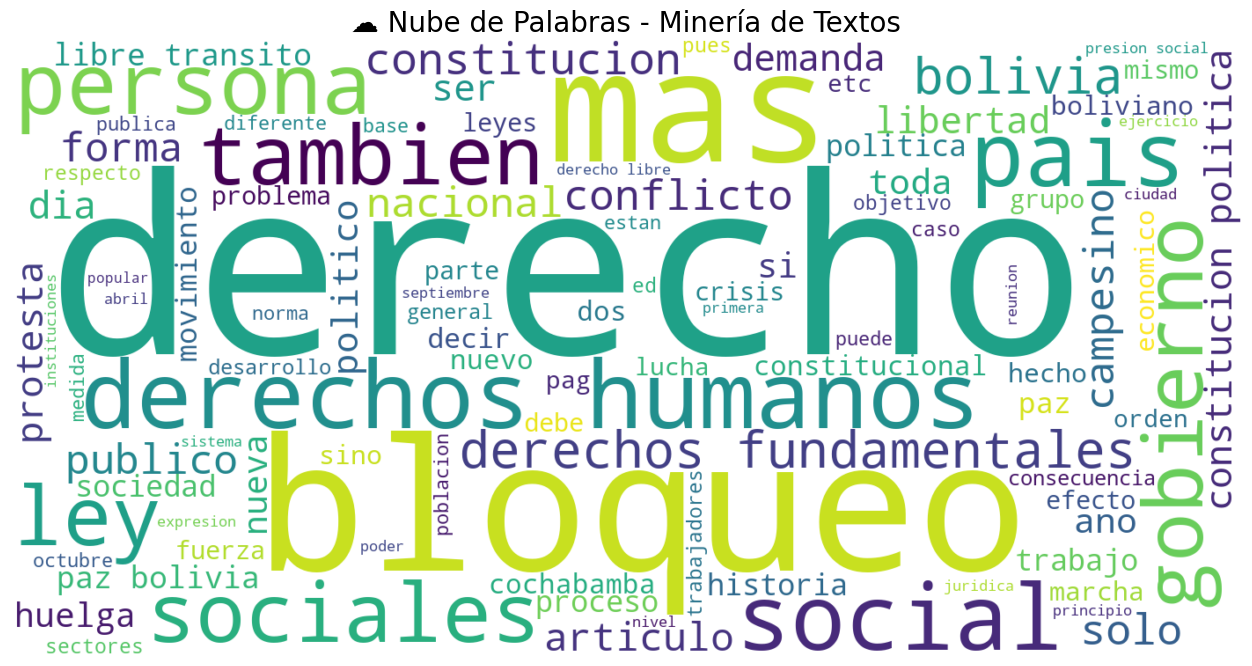

In [24]:
from wordcloud import WordCloud
plt.figure(figsize=(16, 8))
wordcloud = WordCloud(width=1400, height=700, background_color="white", colormap="viridis", max_words=100).generate(documento_final)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("☁️ Nube de Palabras - Minería de Textos", fontsize=20)
plt.show()


## 🏆 Resumen del procesamiento
Presentamos un resumen visual de todas las etapas y procesos realizados, usando iconos y formato destacado.

---

### 🏁 **Etapas ejecutadas:**
- 📂 Preparación de fuentes
- 📥 Adquisición de fuentes
- 🧹 Limpieza del texto
- 🧪 Preparación para el análisis

### ⚙️ **Procesos realizados:**
- 📏 Control de tamaño
- 📝 Extracción de texto PDF
- 🔤 Verificación de codificación
- 🌐 Detección de idioma
- 🧽 Limpieza básica
- 🚫 Eliminación de ruido
- 🧾 Normalización textual
- ✂️ Tokenización
- 🛑 Eliminación de stopwords
- 🌱 Stemming
- 🍃 Lematización
- 📊 Matriz DTM
- 🔄 Matriz TDM
- 📈 Frecuencia de términos
- ☁️ Nube de palabras

### 🎯 **Resultado final:**
El documento PDF fue transformado correctamente en un corpus textual estructurado y preparado para:
- Minería de textos
- NLP
- Clasificación documental
- Clustering
- Análisis semántico
- Ciencia de datos
- Aprendizaje automático

---

🏆 **¡Procesamiento finalizado correctamente!**